# Synthetic data test

Load a synthetic two-modality tissue pair via `mgw.data` and sanity-check it.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt

from mgw.data import synthetic_multimodal_tissue

### Generate

In [2]:
data = synthetic_multimodal_tissue(
    nx=30, ny=20,      # hex grid -> n = nx*ny spots per slice
    K=4,               # cell types
    warp_amp=0.06,     # deformation slice A -> slice B
    dA=6, dB=4,        # features per modality
    seed=0,
    jitter=0.0
)

s, t = data["s"], data["t"]          # spatial coords (n,2) / (m,2)
X, Z = data["X"], data["Z"]          # modality A / B features
labels, sigma = data["labels"], data["sigma"]

for k in ["s", "X", "t", "Z", "labels", "sigma"]:
    print(f"{k:7s}", data[k].shape, data[k].dtype)

s       (600, 2) float32
X       (600, 6) float32
t       (600, 2) float32
Z       (600, 4) float32
labels  (600,) int64
sigma   (600,) int64


### Spatial layout and ground-truth cell types

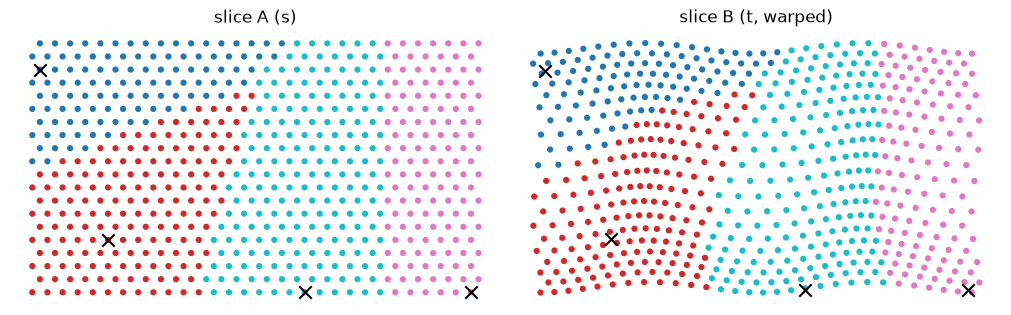

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, (coords, title) in zip(axes, [(s, "slice A (s)"), (t, "slice B (t, warped)")]):
    ax.scatter(coords[:, 0], coords[:, 1], c=labels, cmap="tab10", s=12)
    ax.scatter(*data["centers"].T, c="k", marker="x", s=80)
    ax.set_title(title); ax.set_aspect("equal"); ax.axis("off")
plt.show()

### Feature fields

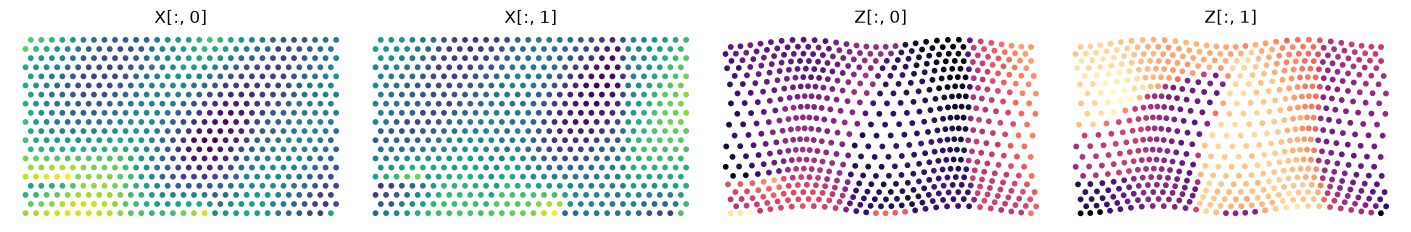

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), constrained_layout=True)
for j, ax in enumerate(axes[:2]):
    ax.scatter(s[:, 0], s[:, 1], c=X[:, j], cmap="viridis", s=10)
    ax.set_title(f"X[:, {j}]")
for j, ax in enumerate(axes[2:]):
    ax.scatter(t[:, 0], t[:, 1], c=Z[:, j], cmap="magma", s=10)
    ax.set_title(f"Z[:, {j}]")
for ax in axes:
    ax.set_aspect("equal"); ax.axis("off")
plt.show()

### Ground-truth correspondence

`sigma` maps each spot in A to its nearest spot in B, i.e. the alignment any method should recover.

In [5]:
disp = np.linalg.norm(t[sigma] - s, axis=1)
print(f"matched pairs: {len(sigma)}, unique targets: {len(np.unique(sigma))}")
print(f"displacement |t[sigma]-s|: mean {disp.mean():.4f}, max {disp.max():.4f}")
print("label agreement A vs B:", (labels == data["pi_t"].argmax(1)[sigma]).mean())

matched pairs: 600, unique targets: 528
displacement |t[sigma]-s|: mean 0.0244, max 0.0608
label agreement A vs B: 0.97


### Preprocessing with `mgw.mgw_preprocess`

Wrap the two slices as `AnnData` (features in `.X`, coords in `.obsm["spatial"]`) and run the
standard preprocessing: unit-square coords + CCA-feeler representations.
The synthetic features are continuous and low-dimensional, so PCA/log1p are switched off
(`PCA_comp` still bounds the feeler's internal PCA, hence the small values).

In [13]:
import anndata as ad
import mgw.mgw as mgw

A = ad.AnnData(X=X.astype(np.float32))
A.obsm["spatial"] = s
A.obs["label"] = labels.astype(str)

B = ad.AnnData(X=Z.astype(np.float32))
B.obsm["spatial"] = t

pre = mgw.mgw_preprocess(
    A, B,
    PCA_comp=3, CCA_comp=2,
    use_cca_feeler=True,
    use_pca_X=False, use_pca_Z=False,   # features are not counts / already low-dim
    log1p_X=False, log1p_Z=False,
    verbose=True,
)

for k in ["xs", "xs2", "X_feat", "Z_feat", "X_rep", "Z_rep"]:
    print(f"{k:7s}", pre[k].shape)

[mgw.pre] PCA/raw shapes: X=(600, 6)  Z=(600, 4)
[mgw.pre] CCA feeler: PCA → small GW (fused) → barycentric → CCA
Computing PCA (3 comps)...
Computing PCA (3 comps)...
Feature shapes -> X: (600, 3) Z: (600, 3)
Feeler GW sizes: X-side 600, Z-side 600
Solving feeler feature alignment.
Computing CCA Components
CCA dims: 2  (applied to full sets)
xs      (600, 2)
xs2     (600, 2)
X_feat  (600, 6)
Z_feat  (600, 4)
X_rep   (600, 2)
Z_rep   (600, 2)


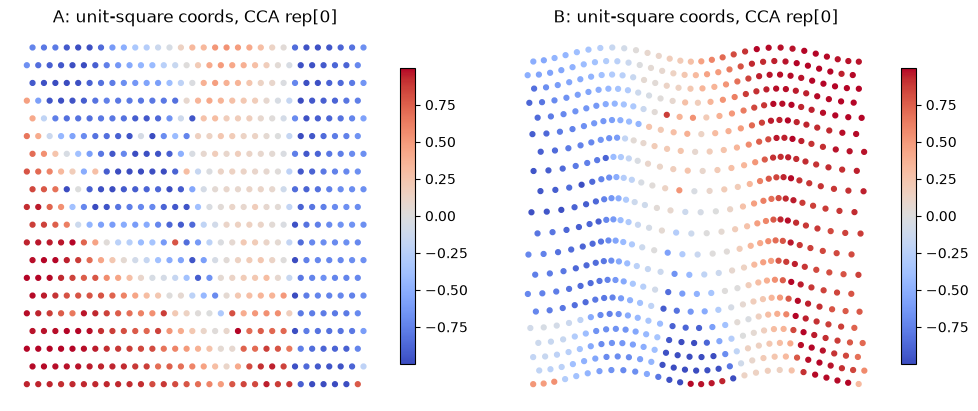

In [14]:
xs, xs2 = pre["xs"], pre["xs2"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, (coords, rep, title) in zip(
    axes, [(xs, pre["X_rep"], "A: unit-square coords, CCA rep[0]"),
           (xs2, pre["Z_rep"], "B: unit-square coords, CCA rep[0]")]):
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=rep[:, 0], cmap="coolwarm", s=12)
    fig.colorbar(sc, ax=ax, shrink=0.8)
    ax.set_title(title); ax.set_aspect("equal"); ax.axis("off")
plt.show()